✅ Number of samples in Cluster 3: 1
✅ Selected top 25 features: ['Current_Asset_Turnover_Rate', 'Quick_Asset_Turnover_Rate', 'Working_capitcal_Turnover_Rate', 'Cash_Turnover_Rate', 'Cash_Flow_to_Sales', 'Fixed_Assets_to_Assets', 'Current_Liability_to_Liability', 'Current_Liability_to_Equity', 'Equity_to_Long-term_Liability', 'Cash_Flow_to_Total_Assets', 'Cash_Flow_to_Liability', 'CFO_to_Assets', 'Cash_Flow_to_Equity', 'Current_Liability_to_Current_Assets', 'Liability-Assets_Flag', 'Net_Income_to_Total_Assets', 'Total_assets_to_GNP_price', 'No-credit_Interval', 'Gross_Profit_to_Sales', "Net_Income_to_Stockholder's_Equity", 'Liability_to_Equity', 'Degree_of_Financial_Leverage_(DFL)', 'Interest_Coverage_Ratio_(Interest_expense_to_EBIT)', 'Net_Income_Flag', 'Equity_to_Liability']

Dummy Classifier Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

Not Bankrupt       0.00      0.00      0.00         0
    Bankrupt       1.00      1.00      1.00     

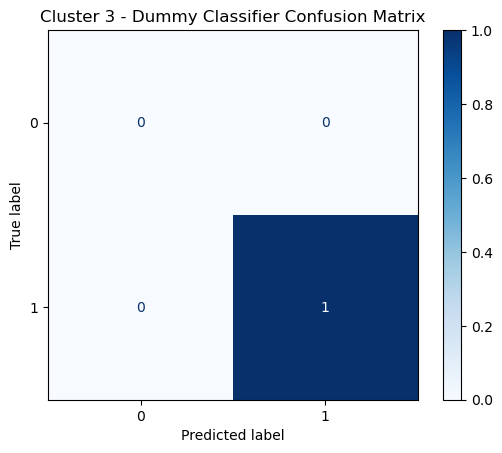


📁 Model, scaler, and selected features saved to 'cluster3_output/'


In [9]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Suppress warnings
warnings.filterwarnings("ignore")

# 1. Load data and filter Cluster 3
cluster_id = 3
df = pd.read_csv("train_with_clusters.csv")
df_cluster = df[df["ClusterID"] == cluster_id].copy()

if df_cluster.empty:
    print(f"❌ Cluster {cluster_id} has no data.")
else:
    print(f"✅ Number of samples in Cluster {cluster_id}: {len(df_cluster)}")

    # 2. Separate features and target
    X = df_cluster.drop(columns=["Index", "Bankrupt?", "ClusterID"])
    y = df_cluster["Bankrupt?"]

    # 3. Feature Selection: SelectKBest(f_classif)
    selector = SelectKBest(score_func=f_classif, k=min(25, X.shape[1]))
    X_selected = selector.fit_transform(X, y)
    selected_features = X.columns[selector.get_support()]
    X = X[selected_features]

    print(f"✅ Selected top {len(selected_features)} features: {list(selected_features)}")

    # 4. Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5. Dummy Classifier
    dummy_model = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy_model.fit(X_scaled, y)
    y_pred = dummy_model.predict(X_scaled)

    # 6. Evaluation
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred, labels=[0, 1])  # Force both labels

    print(f"\nDummy Classifier Accuracy: {acc:.2f}")
    print("Classification Report:")
    print(classification_report(
        y, y_pred, labels=[0, 1],
        target_names=["Not Bankrupt", "Bankrupt"], zero_division=0
    ))

    # 7. Confusion Matrix Display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Cluster {cluster_id} - Dummy Classifier Confusion Matrix")
    plt.show()

    # 8. Save Model Artifacts
    output_dir = f"cluster{cluster_id}_output"
    os.makedirs(output_dir, exist_ok=True)

    joblib.dump(dummy_model, f'{output_dir}/stacked_model_cluster{cluster_id}.pkl')
    joblib.dump(scaler, f'{output_dir}/scaler_cluster{cluster_id}.pkl')
    joblib.dump(list(selected_features), f'{output_dir}/cluster{cluster_id}_features.pkl')

    with open(f"{output_dir}/selected_features_cluster{cluster_id}.txt", "w") as f:
        for feat in selected_features:
            f.write(f"{feat}\n")

    print(f"\n📁 Model, scaler, and selected features saved to '{output_dir}/'")